<a href="https://colab.research.google.com/github/joshuammelcrak-art/Estocasticos/blob/main/Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial básico de matrices en SymPy y diagramas en NetworkX

---

##1. Trabajando con matrices en SymPy

Primero importamos la librería:

In [5]:
import sympy as sp

---

##Crear una matriz

Podemos crear una matriz escribiendo las filas como listas:

In [6]:
A = sp.Matrix([[3, 8],
               [4, 2]])

A

Matrix([
[3, 8],
[4, 2]])

---

##Obtener una entrada específica

Para acceder a un elemento usamos la forma [fila, columna].

En Python se empieza desde 0.

In [12]:
A[0, 1]   # fila 0, columna 1

8

También podemos obtener una fila o columna completa:

In [13]:
A.row(0)      # primera fila
A.col(1)      # segunda columna

Matrix([
[8],
[2]])

---

##Multiplicar matrices

Creamos otra matriz:

In [14]:
B = sp.Matrix([[7, 2],
               [3, 5]])

B

Matrix([
[7, 2],
[3, 5]])

Multiplicamos así:

In [15]:
C = A * B
C

Matrix([
[45, 46],
[34, 18]])

---

##Elevar una matriz a una potencia

Por ejemplo, elevar A al cuadrado:

In [16]:
A2 = A**2
A2

Matrix([
[41, 40],
[20, 36]])

Esto equivale a hacer
$ A⋅A$ .

---

##Multiplicar matriz por vector

Creamos un vector columna:

In [18]:
v = sp.Matrix([[3],
               [9]])

v

Matrix([
[3],
[9]])

Multiplicamos:

In [19]:
resultado = A * v
resultado

Matrix([
[81],
[30]])

---

##Valores y vectores propios

Para obtener los valores propios:

In [20]:
A.eigenvals()

{5/2 - sqrt(129)/2: 1, 5/2 + sqrt(129)/2: 1}

Para obtener los vectores propios:

In [21]:
A.eigenvects()

[(5/2 - sqrt(129)/2,
  1,
  [Matrix([
   [1/8 - sqrt(129)/8],
   [                1]])]),
 (5/2 + sqrt(129)/2,
  1,
  [Matrix([
   [1/8 + sqrt(129)/8],
   [                1]])])]

Esto devuelve una lista con:

* valor propio

* multiplicidad

* vectores propios asociados

---

#2. Diagrama de transición con NetworkX

Ahora usamos NetworkX para dibujar un diagrama sencillo.

Primero importamos:

In [22]:
import networkx as nx
import matplotlib.pyplot as plt

---

##Crear un grafo dirigido

Un diagrama de transición normalmente es un grafo dirigido.

In [23]:
G = nx.DiGraph()

---

##Agregar nodos

In [24]:
G.add_nodes_from(["A", "B", "C"])

---

##Agregar transiciones (aristas)

In [25]:
G.add_edge("A", "B")
G.add_edge("B", "C")
G.add_edge("C", "A")
G.add_edge("A", "C")

---

##Dibujar el diagrama

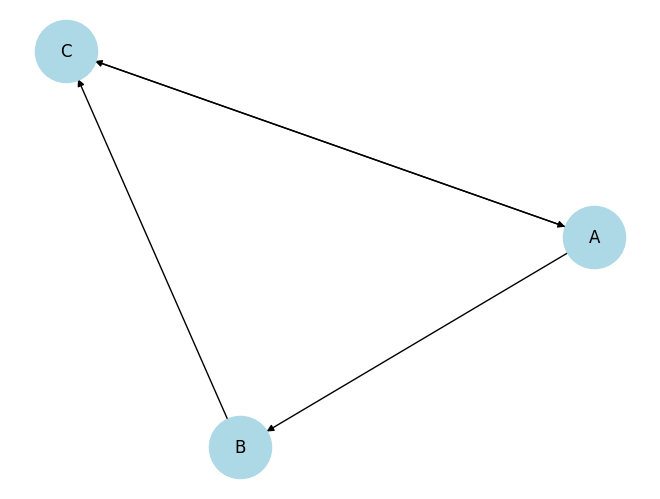

In [26]:
pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_color="lightblue",
        node_size=2000, font_size=12)

plt.show()

Esto genera un diagrama donde las flechas indican las transiciones.

---

##Ejemplo sencillo tipo matriz de transición

Si tenemos la matriz:

In [67]:
P = sp.Matrix([[0.3, 0.7],
               [0.4, 0.6]])

P

Matrix([
[0.3, 0.7],
[0.4, 0.6]])

Podemos interpretar que:

Del estado 1 se pasa al 1 con 3 y al 2 con 5

Del estado 2 se pasa al 1 con 4 y al 2 con 2

Y eso se puede representar como un grafo dirigido con pesos si se desea.

---

##Creamos el grafo

In [68]:
G = nx.DiGraph()

---

##Agregamos los estados

In [69]:
G.add_nodes_from(["1", "2"])

---

##Agregar las transiciones

Cada entrada de la matriz representa una transición.

In [70]:
G.add_edge("1", "1", weight=0.3)
G.add_edge("1", "2", weight=0.7)
G.add_edge("2", "1", weight=0.4)
G.add_edge("2", "2", weight=0.6)

---

##Dibujar el grafo

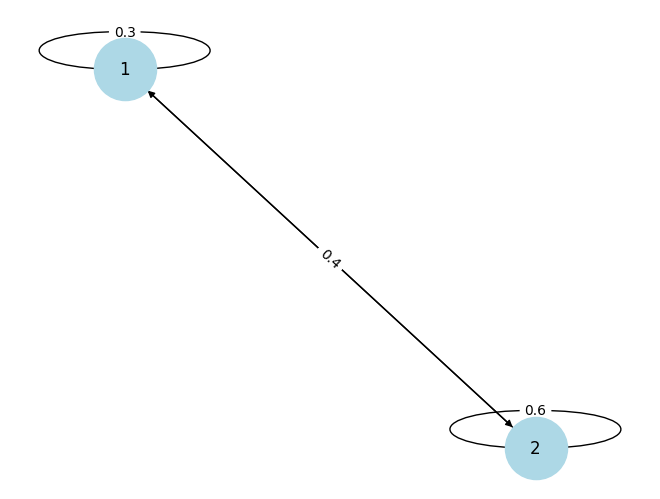

In [72]:
pos = nx.spring_layout(G)

nx.draw(G, pos,
        with_labels=True,
        node_color="lightblue",
        node_size=2000,
        font_size=12,
        arrows=True)

labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.show()

---

##Interpretación

El diagrama muestra los estados del sistema como nodos y las probabilidades de transición como flechas entre ellos.

Por ejemplo:

La flecha 1 → 2 con etiqueta 0.4 indica que hay probabilidad 0.4 de pasar del estado 1 al estado 2.

La flecha 2 → 2 con etiqueta 0.6 indica que hay probabilidad 0.6 de pasar del estado 2 al estado 2.

Este tipo de representación es común en cadenas de Markov, donde la matriz de transición describe cómo evoluciona el sistema entre estados.

---